In [ ]:
import pandas as pd

In [ ]:

results_folder = f'LFR_Graph_Data/Community_Data/Infomap/results/mu_0_2'

In [ ]:
df = pd.read_csv(f'{results_folder}/y_train.csv')

In [6]:
import os
import pandas as pd
import numpy as np
from pathlib import Path

def load_stability_stats(base_path, algorithm, mu_values):
    """
    Carrega os rótulos já classificados pelo K-means (y_train.csv)
    """
    results = []
    
    for mu in mu_values:
        mu_str = str(mu).replace('.', '_')
        mu_dir = f'mu_{mu_str}'
        
        labels_path = Path(base_path) / algorithm / 'results' / mu_dir
        
        if not labels_path.exists():
            print(f"⚠️ Caminho não encontrado: {labels_path}")
            continue
        
        label_files = list(labels_path.glob('*y_train.csv'))
        
        if not label_files:
            print(f"⚠️ Nenhum arquivo y_train.csv encontrado em: {labels_path}")
            continue
        
        print(f"📊 {algorithm.upper()}, μ={mu}: {len(label_files)} arquivos")
        
        unstable_ratios = []
        total_nodes = 0
        total_unstable = 0
        
        for file in label_files:
            try:
                df = pd.read_csv(file)
                
                # Identifica coluna de rótulos
                label_col = [col for col in df.columns if 'label' in col.lower() or 'y' in col.lower() or 'Stability' in col]
                if not label_col:
                    label_col = df.columns[0]
                else:
                    label_col = label_col[0]
                
                labels = df[label_col].values
                n_nodes = len(labels)
                n_unstable = np.sum(labels == 1)
                
                unstable_ratios.append(n_unstable / n_nodes)
                total_nodes += n_nodes
                total_unstable += n_unstable
                
            except Exception as e:
                print(f"  ❌ Erro: {file.name} - {e}")
                continue
        
        if unstable_ratios:
            stats = {
                'algorithm': f"{algorithm.upper()} (μ={mu})",
                'total_nodes': total_nodes,
                'total_unstable_percent': (total_unstable / total_nodes) * 100,
                'mean_percent': np.mean(unstable_ratios) * 100,
                'median_percent': np.median(unstable_ratios) * 100,
                'std_percent': np.std(unstable_ratios) * 100
            }
            results.append(stats)
    
    return pd.DataFrame(results)


def main():
    base_path = "LFR_Graph_Data/Community_Data"
    algorithms = ['Infomap', 'louvain', 'lpa']
    mu_values = [0.2, 0.3, 0.4]
    
    print("=" * 70)
    print("ANÁLISE DE ESTABILIDADE - NÓS INSTÁVEIS")
    print("=" * 70)
    
    all_results = []
    
    for algorithm in algorithms:
        print(f"\n▶️ {algorithm.upper()}")
        df = load_stability_stats(base_path, algorithm, mu_values)
        if not df.empty:
            all_results.append(df)
    
    if not all_results:
        print("\n❌ Nenhum dado encontrado.")
        return
    
    master_df = pd.concat(all_results, ignore_index=True)
    
    # Tabela final
    print("\n" + "=" * 70)
    print("RESULTADOS - PROPORÇÃO DE NÓS INSTÁVEIS")
    print("=" * 70)
    
    result_table = master_df[['algorithm', 'total_unstable_percent', 
                              'mean_percent', 'median_percent', 
                              'std_percent', 'total_nodes']].copy()
    
    result_table.columns = ['Algoritmo (μ)', '% Instável', 'Média (%)', 
                            'Mediana (%)', 'Desv.Pad (%)', 'Total Nós']
    
    # Formatação
    for col in ['% Instável', 'Média (%)', 'Mediana (%)', 'Desv.Pad (%)']:
        result_table[col] = result_table[col].map('{:.1f}'.format)
    result_table['Total Nós'] = result_table['Total Nós'].map('{:,}'.format)
    
    print(result_table.to_string(index=False))
    
    # Salva
    master_df.to_csv("stability_stats_summary.csv", index=False)
    print("\n💾 Salvo: stability_stats_summary.csv")
    
    return master_df


if __name__ == "__main__":
    df = main()

ANÁLISE DE ESTABILIDADE - NÓS INSTÁVEIS

▶️ INFOMAP
📊 INFOMAP, μ=0.2: 1 arquivos
📊 INFOMAP, μ=0.3: 1 arquivos
📊 INFOMAP, μ=0.4: 1 arquivos

▶️ LOUVAIN
📊 LOUVAIN, μ=0.2: 1 arquivos
📊 LOUVAIN, μ=0.3: 1 arquivos
📊 LOUVAIN, μ=0.4: 1 arquivos

▶️ LPA
📊 LPA, μ=0.2: 1 arquivos
📊 LPA, μ=0.3: 1 arquivos
⚠️ Caminho não encontrado: LFR_Graph_Data/Community_Data/lpa/results/mu_0_4

RESULTADOS - PROPORÇÃO DE NÓS INSTÁVEIS
  Algoritmo (μ) % Instável Média (%) Mediana (%) Desv.Pad (%) Total Nós
INFOMAP (μ=0.2)      100.0     100.0       100.0          0.0       800
INFOMAP (μ=0.3)      100.0     100.0       100.0          0.0       800
INFOMAP (μ=0.4)      100.0     100.0       100.0          0.0       800
LOUVAIN (μ=0.2)       43.7      43.7        43.7          0.0        87
LOUVAIN (μ=0.3)       43.0      43.0        43.0          0.0       128
LOUVAIN (μ=0.4)       42.8      42.8        42.8          0.0       705
    LPA (μ=0.2)       43.0      43.0        43.0          0.0       540
    LPA (μ=

DIAGNÓSTICO DA MATRIZ DE CO-ASSOCIAÇÃO
Arquivo: /home/paulomelo/Documents/TCC/CommunityFinding/CommunityFindingXAIwithALE/LFR_Graph_Data/Community_Data/Infomap/rCoassociation/graph_01_mu_0_3_coassociation.npy
----------------------------------------------------------------------

📊 Informações básicas:
   Shape: (1000, 1000)
   Tipo: float32
   Memória: 3.81 MB

📈 Estatísticas dos valores:
   Valores únicos: [0. 1.]
   Número de valores únicos: 2
   Mínimo: 0.000000
   Máximo: 1.000000
   Média: 0.084494
   Mediana: 0.000000

🔍 Diagnóstico:
   ⚠️ PROBLEMA DETECTADO: Matriz contém APENAS 0 e 1
      → Todas as execuções produziram partições IDÊNTICAS
      → NÃO há variabilidade entre as execuções
      → Entropia será ZERO para todos os nós
      → Proporção de pares na mesma comunidade: 0.084
      → Matriz é simétrica: True

📊 Entropia por nó (E_i):
   Média: 0.000000
   Mediana: 0.000000
   Desvio padrão: 0.000000
   Mínimo: 0.000000
   Máximo: 0.000000
   Proporção de nós com entro

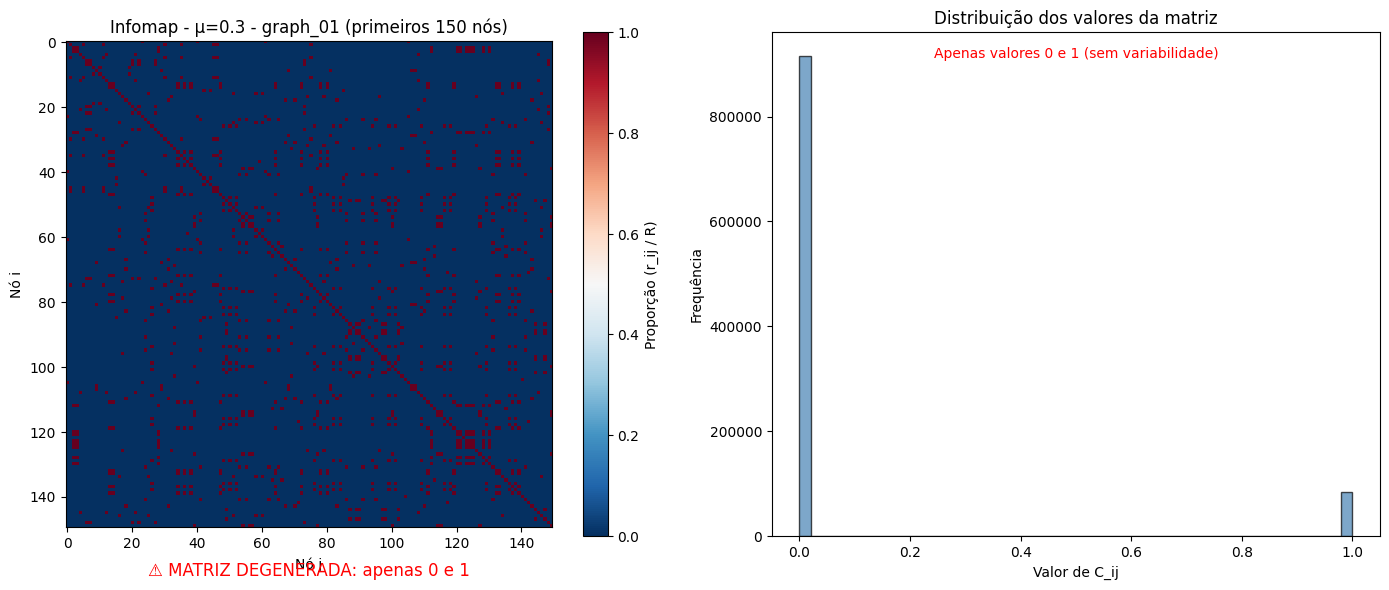


💾 Entropias salvas em: infomap_mu_03_entropies_calculated.csv


In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

def diagnose_coassociation_matrix(file_path):
    """
    Diagnostica uma matriz de co-associação específica
    
    Parâmetros:
    - file_path: caminho completo para o arquivo .npy
    """
    
    print("=" * 70)
    print(f"DIAGNÓSTICO DA MATRIZ DE CO-ASSOCIAÇÃO")
    print("=" * 70)
    print(f"Arquivo: {file_path}")
    print("-" * 70)
    
    # Carrega matriz
    C = np.load(file_path)
    print(f"\n📊 Informações básicas:")
    print(f"   Shape: {C.shape}")
    print(f"   Tipo: {C.dtype}")
    print(f"   Memória: {C.nbytes / 1024 / 1024:.2f} MB")
    
    # Estatísticas dos valores
    unique_values = np.unique(C)
    print(f"\n📈 Estatísticas dos valores:")
    print(f"   Valores únicos: {unique_values[:10]}{'...' if len(unique_values) > 10 else ''}")
    print(f"   Número de valores únicos: {len(unique_values)}")
    print(f"   Mínimo: {C.min():.6f}")
    print(f"   Máximo: {C.max():.6f}")
    print(f"   Média: {C.mean():.6f}")
    print(f"   Mediana: {np.median(C):.6f}")
    
    # Verifica caso degenerado (apenas 0 e 1)
    is_binary = np.all(np.isin(C, [0, 1]))
    print(f"\n🔍 Diagnóstico:")
    
    if is_binary:
        print("   ⚠️ PROBLEMA DETECTADO: Matriz contém APENAS 0 e 1")
        print("      → Todas as execuções produziram partições IDÊNTICAS")
        print("      → NÃO há variabilidade entre as execuções")
        print("      → Entropia será ZERO para todos os nós")
        
        proportion_same = C.mean()
        print(f"      → Proporção de pares na mesma comunidade: {proportion_same:.3f}")
        
        # Verifica simetria
        is_symmetric = np.allclose(C, C.T, atol=1e-10)
        print(f"      → Matriz é simétrica: {is_symmetric}")
        
    else:
        # Verifica se há valores fracionários
        fractional = unique_values[(unique_values > 0) & (unique_values < 1)]
        print(f"   ✅ Comportamento NORMAL: Matriz contém valores fracionários")
        print(f"      → Valores entre 0 e 1: {len(fractional)} valores únicos")
        print(f"      → Exemplos: {fractional[:5]}")
        print("      → Há variabilidade entre as execuções")
        print("      → Entropias serão NÃO-zero para alguns nós")
    
    # Calcula entropia por nó
    entropies = compute_entropy_from_coassociation(C)
    
    print(f"\n📊 Entropia por nó (E_i):")
    print(f"   Média: {np.mean(entropies):.6f}")
    print(f"   Mediana: {np.median(entropies):.6f}")
    print(f"   Desvio padrão: {np.std(entropies):.6f}")
    print(f"   Mínimo: {np.min(entropies):.6f}")
    print(f"   Máximo: {np.max(entropies):.6f}")
    print(f"   Proporção de nós com entropia = 0: {np.mean(entropies == 0):.2%}")
    print(f"   Proporção de nós com entropia > 0: {np.mean(entropies > 0):.2%}")
    
    # Análise da distribuição
    print(f"\n📊 Distribuição das entropias (percentis):")
    for p in [10, 25, 50, 75, 90]:
        print(f"   {p}º percentil: {np.percentile(entropies, p):.6f}")
    
    return C, entropies


def compute_entropy_from_coassociation(C):
    """
    Calcula entropia por nó a partir da matriz de co-associação
    
    Fórmula: E_i = (1/N) * sum_j p_ij
    onde p_ij = C_ij * log2(C_ij) se C_ij > 0, senão 0
    """
    N = C.shape[0]
    entropies = np.zeros(N)
    
    for i in range(N):
        # Evita calcular log(0) e otimiza para valores 0 e 1
        row = C[i]
        # Apenas valores entre 0 e 1 (exclusive) contribuem
        mask = (row > 0) & (row < 1)
        if np.any(mask):
            p_ij = row[mask] * np.log2(row[mask])
            entropies[i] = np.sum(p_ij) / N
        # Se todos são 0 ou 1, entropia permanece 0
    
    return entropies


def plot_coassociation_heatmap(C, title=None, max_nodes=200):
    """
    Plota heatmap da matriz de co-associação
    """
    if title is None:
        title = "Matriz de Co-associação"
    
    # Limita o tamanho para visualização
    n_plot = min(max_nodes, C.shape[0])
    C_subset = C[:n_plot, :n_plot]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Heatmap completo
    im1 = axes[0].imshow(C_subset, cmap='RdBu_r', interpolation='nearest', vmin=0, vmax=1)
    axes[0].set_title(f"{title} (primeiros {n_plot} nós)", fontsize=12)
    axes[0].set_xlabel("Nó j")
    axes[0].set_ylabel("Nó i")
    plt.colorbar(im1, ax=axes[0], label="Proporção (r_ij / R)")
    
    # Histograma dos valores
    values = C.flatten()
    # Remove valores 0 e 1 para melhor visualização (se existirem)
    fractional_values = values[(values > 0) & (values < 1)]
    
    axes[1].hist(values, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    axes[1].set_title("Distribuição dos valores da matriz", fontsize=12)
    axes[1].set_xlabel("Valor de C_ij")
    axes[1].set_ylabel("Frequência")
    
    # Adiciona anotação sobre degeneração
    if np.all(np.isin(C, [0, 1])):
        axes[0].text(0.5, -0.1, "⚠️ MATRIZ DEGENERADA: apenas 0 e 1", 
                    transform=axes[0].transAxes, ha='center', fontsize=12, color='red')
        axes[1].text(0.5, 0.95, "Apenas valores 0 e 1 (sem variabilidade)", 
                    transform=axes[1].transAxes, ha='center', fontsize=10, color='red')
    
    plt.tight_layout()
    return fig


def compare_coassociation_matrices(file_paths, labels=None):
    """
    Compara múltiplas matrizes de co-associação
    """
    print("\n" + "=" * 70)
    print("COMPARAÇÃO ENTRE MATRIZES")
    print("=" * 70)
    
    results = []
    
    for i, file_path in enumerate(file_paths):
        C = np.load(file_path)
        entropies = compute_entropy_from_coassociation(C)
        
        label = labels[i] if labels else Path(file_path).name
        
        results.append({
            'arquivo': label,
            'shape': C.shape,
            'valores_unicos': len(np.unique(C)),
            'apenas_0_1': np.all(np.isin(C, [0, 1])),
            'entropia_media': np.mean(entropies),
            'entropia_max': np.max(entropies),
            'prop_zero_entropy': np.mean(entropies == 0),
            'prop_pos_entropy': np.mean(entropies > 0)
        })
    
    df = pd.DataFrame(results)
    print(df.to_string(index=False))
    
    return df


# ============================================================================
# EXECUÇÃO PRINCIPAL
# ============================================================================

if __name__ == "__main__":
    
    # Arquivo específico que você forneceu
    file_path = "/home/paulomelo/Documents/TCC/CommunityFinding/CommunityFindingXAIwithALE/LFR_Graph_Data/Community_Data/Infomap/rCoassociation/graph_01_mu_0_3_coassociation.npy"
    
    # Verifica se o arquivo existe
    if Path(file_path).exists():
        # Diagnóstico completo
        C, entropies = diagnose_coassociation_matrix(file_path)
        
        # Visualização
        fig = plot_coassociation_heatmap(C, title=f"Infomap - μ=0.3 - graph_01", max_nodes=150)
        plt.savefig("infomap_mu_03_coassociation_heatmap.png", dpi=150, bbox_inches='tight')
        plt.show()
        
        # Salva entropias calculadas
        entropy_df = pd.DataFrame({
            'node': [f"node_{i}" for i in range(len(entropies))],
            'entropy': entropies
        })
        entropy_df.to_csv("infomap_mu_03_entropies_calculated.csv", index=False)
        print(f"\n💾 Entropias salvas em: infomap_mu_03_entropies_calculated.csv")
        
    else:
        print(f"❌ Arquivo não encontrado: {file_path}")
        
        # Tenta encontrar arquivos alternativos
        base_dir = Path("/LFR_Graph_Data/Community_Data/Infomap/rCoassociation")
        
        if base_dir.exists():
            print(f"\n📂 Procurando arquivos em: {base_dir}")
            files = list(base_dir.glob("*.npy"))
            if files:
                print(f"   Encontrados {len(files)} arquivos:")
                for f in files[:5]:
                    print(f"     - {f.name}")
            else:
                print("   Nenhum arquivo .npy encontrado")